In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import parse_slurm as ps
import data_analysis as da
import glob
import pandas as pd

In [3]:
metric = 'ConsumedEnergy'

# Docking Protein-Protein Energy Analysis 

In [4]:
dpp = pd.read_csv('./data/clean/data_dpp.csv')
dpp_energy = dpp[['ConsumedEnergy', 'NCPUS']]

In [5]:
dpp_energy.loc[:, 'ConsumedEnergy'] = dpp_energy['ConsumedEnergy'] / 1000

## Descriptive Analysis

In [6]:
for x in [4, 8, 16, 32]:
    group = ps.get_group(dpp_energy, ncpus=x)
    print(group.describe())

       ConsumedEnergy  NCPUS
count       13.000000   13.0
mean         0.488897    4.0
std          0.038217    0.0
min          0.447040    4.0
25%          0.453370    4.0
50%          0.479090    4.0
75%          0.514220    4.0
max          0.577770    4.0
       ConsumedEnergy  NCPUS
count       16.000000   16.0
mean         0.302669    8.0
std          0.019862    0.0
min          0.281230    8.0
25%          0.283067    8.0
50%          0.299185    8.0
75%          0.322325    8.0
max          0.329010    8.0
       ConsumedEnergy  NCPUS
count       10.000000   10.0
mean         0.220896   16.0
std          0.013043    0.0
min          0.198510   16.0
25%          0.214543   16.0
50%          0.229235   16.0
75%          0.230150   16.0
max          0.231150   16.0
       ConsumedEnergy  NCPUS
count       13.000000   13.0
mean         0.189088   32.0
std          0.011158    0.0
min          0.176320   32.0
25%          0.177120   32.0
50%          0.195380   32.0
75%          0

## Boxplots

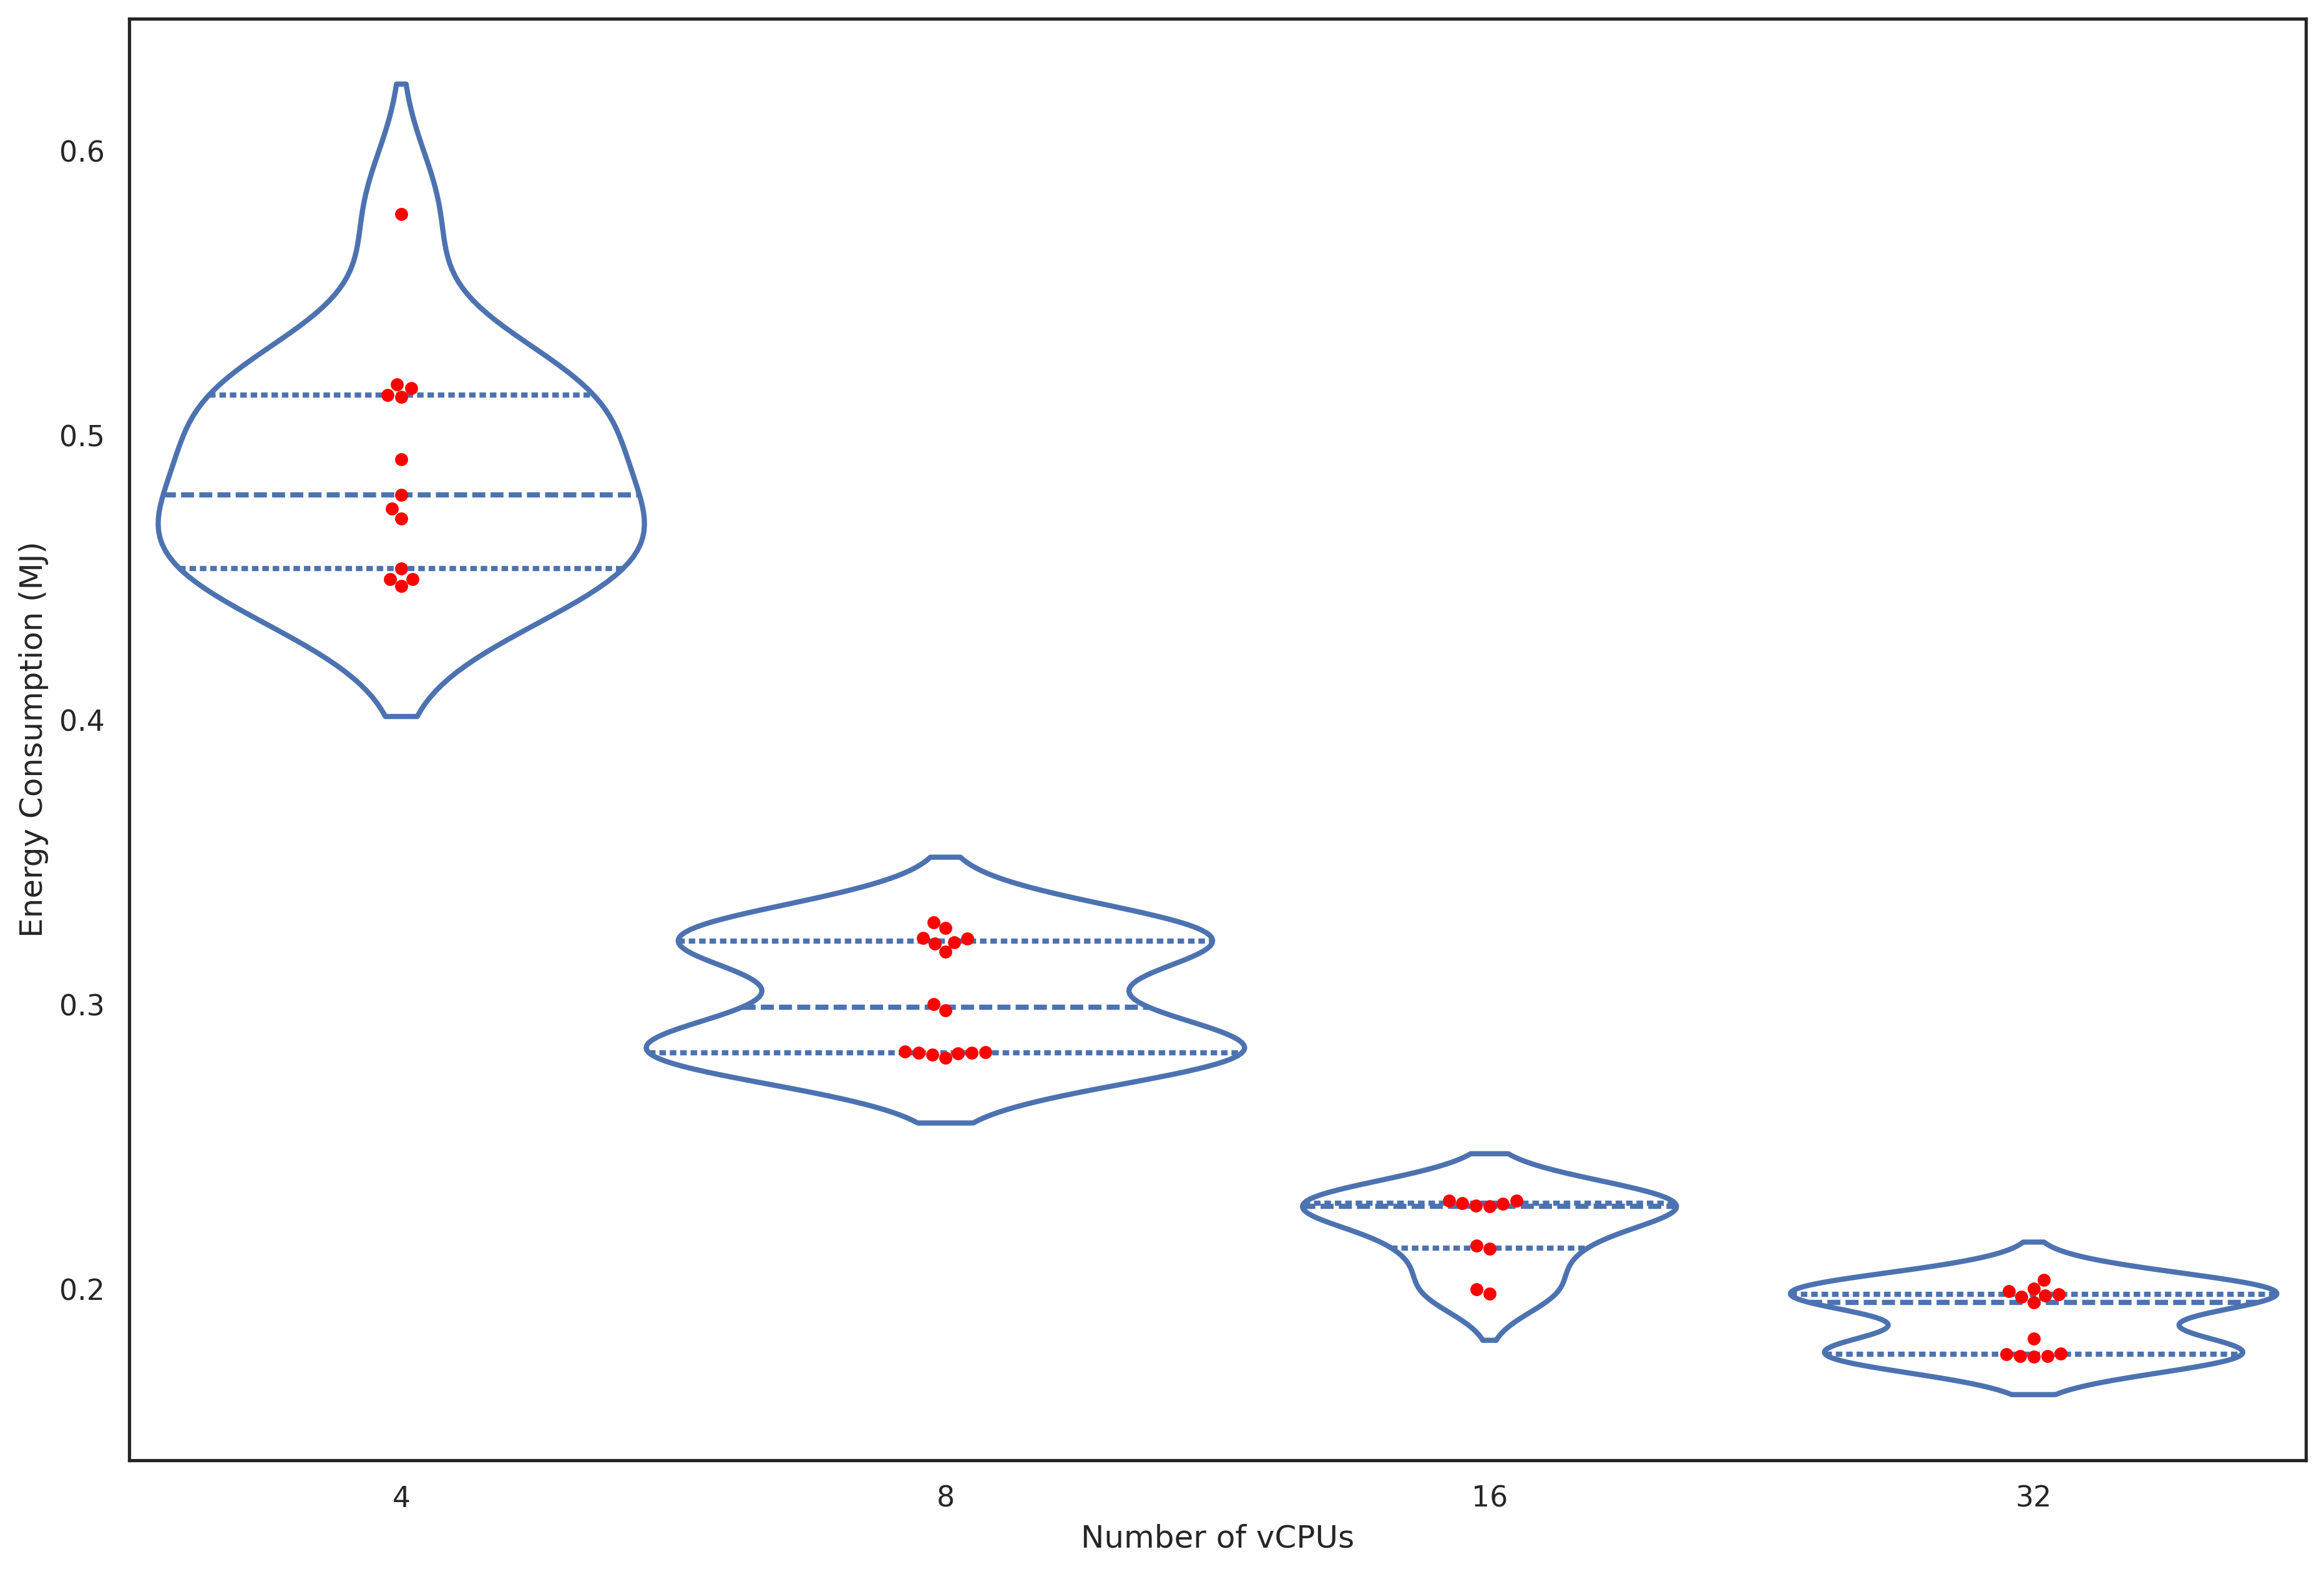

In [7]:
da.show_boxplot(
    dpp_energy, "Energy Consumption of DPP Workflow at Varying Parallelism Degrees", metric='ConsumedEnergy',
    x_label="Number of vCPUs", y_label="Energy Consumption (MJ)", store=True
)

### Normality Test: Shapiro-Wilk and QQ-Plots

In [8]:
normality = ps.test_normality(dpp_energy, column=metric)
print(normality)

   NCPUS      STAT    PVALUE
0      4  0.892077  0.104140
1      8  0.790882  0.002066
2     16  0.762255  0.005032
3     32  0.792577  0.005571


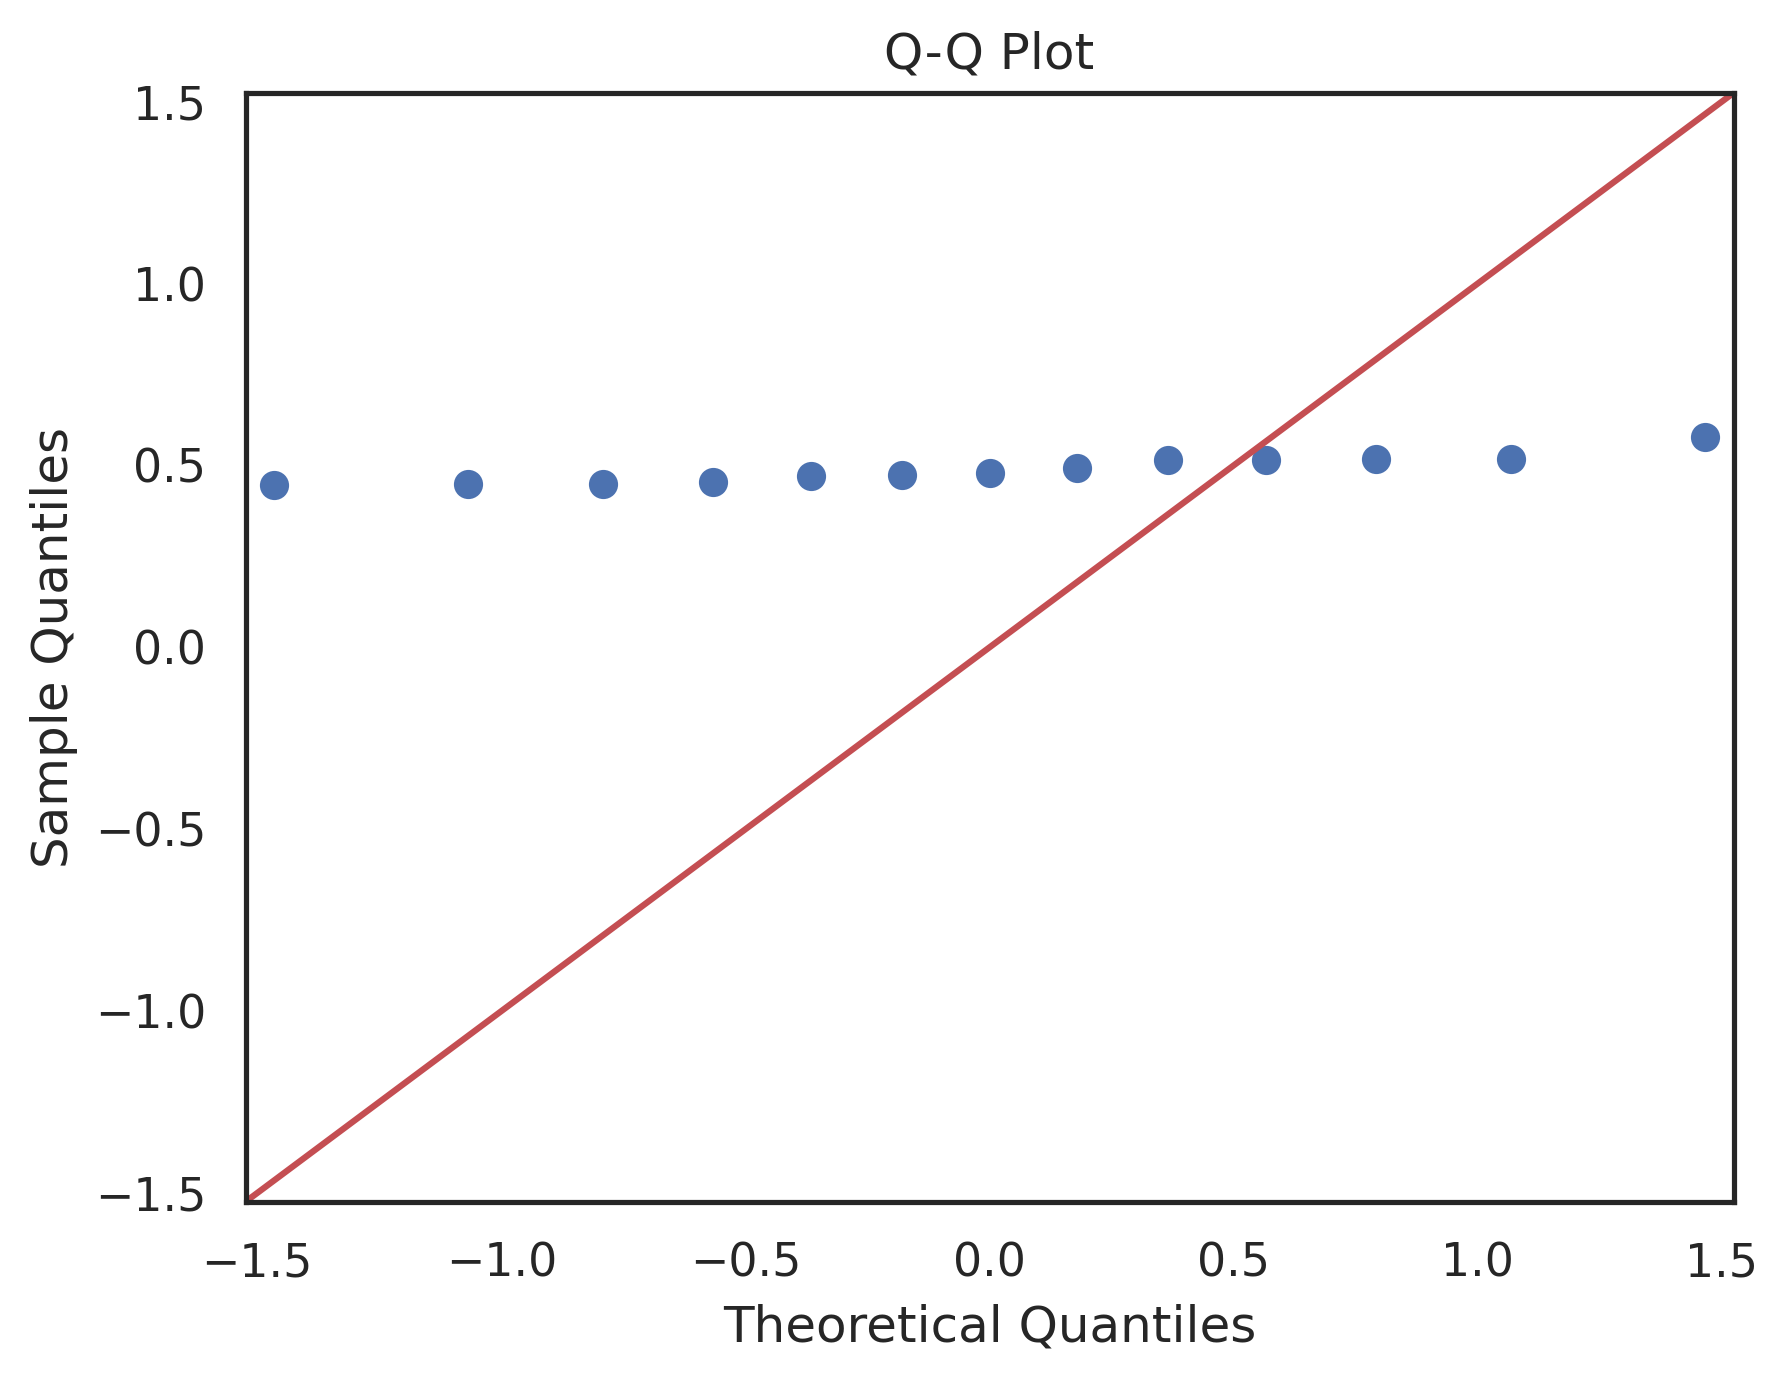

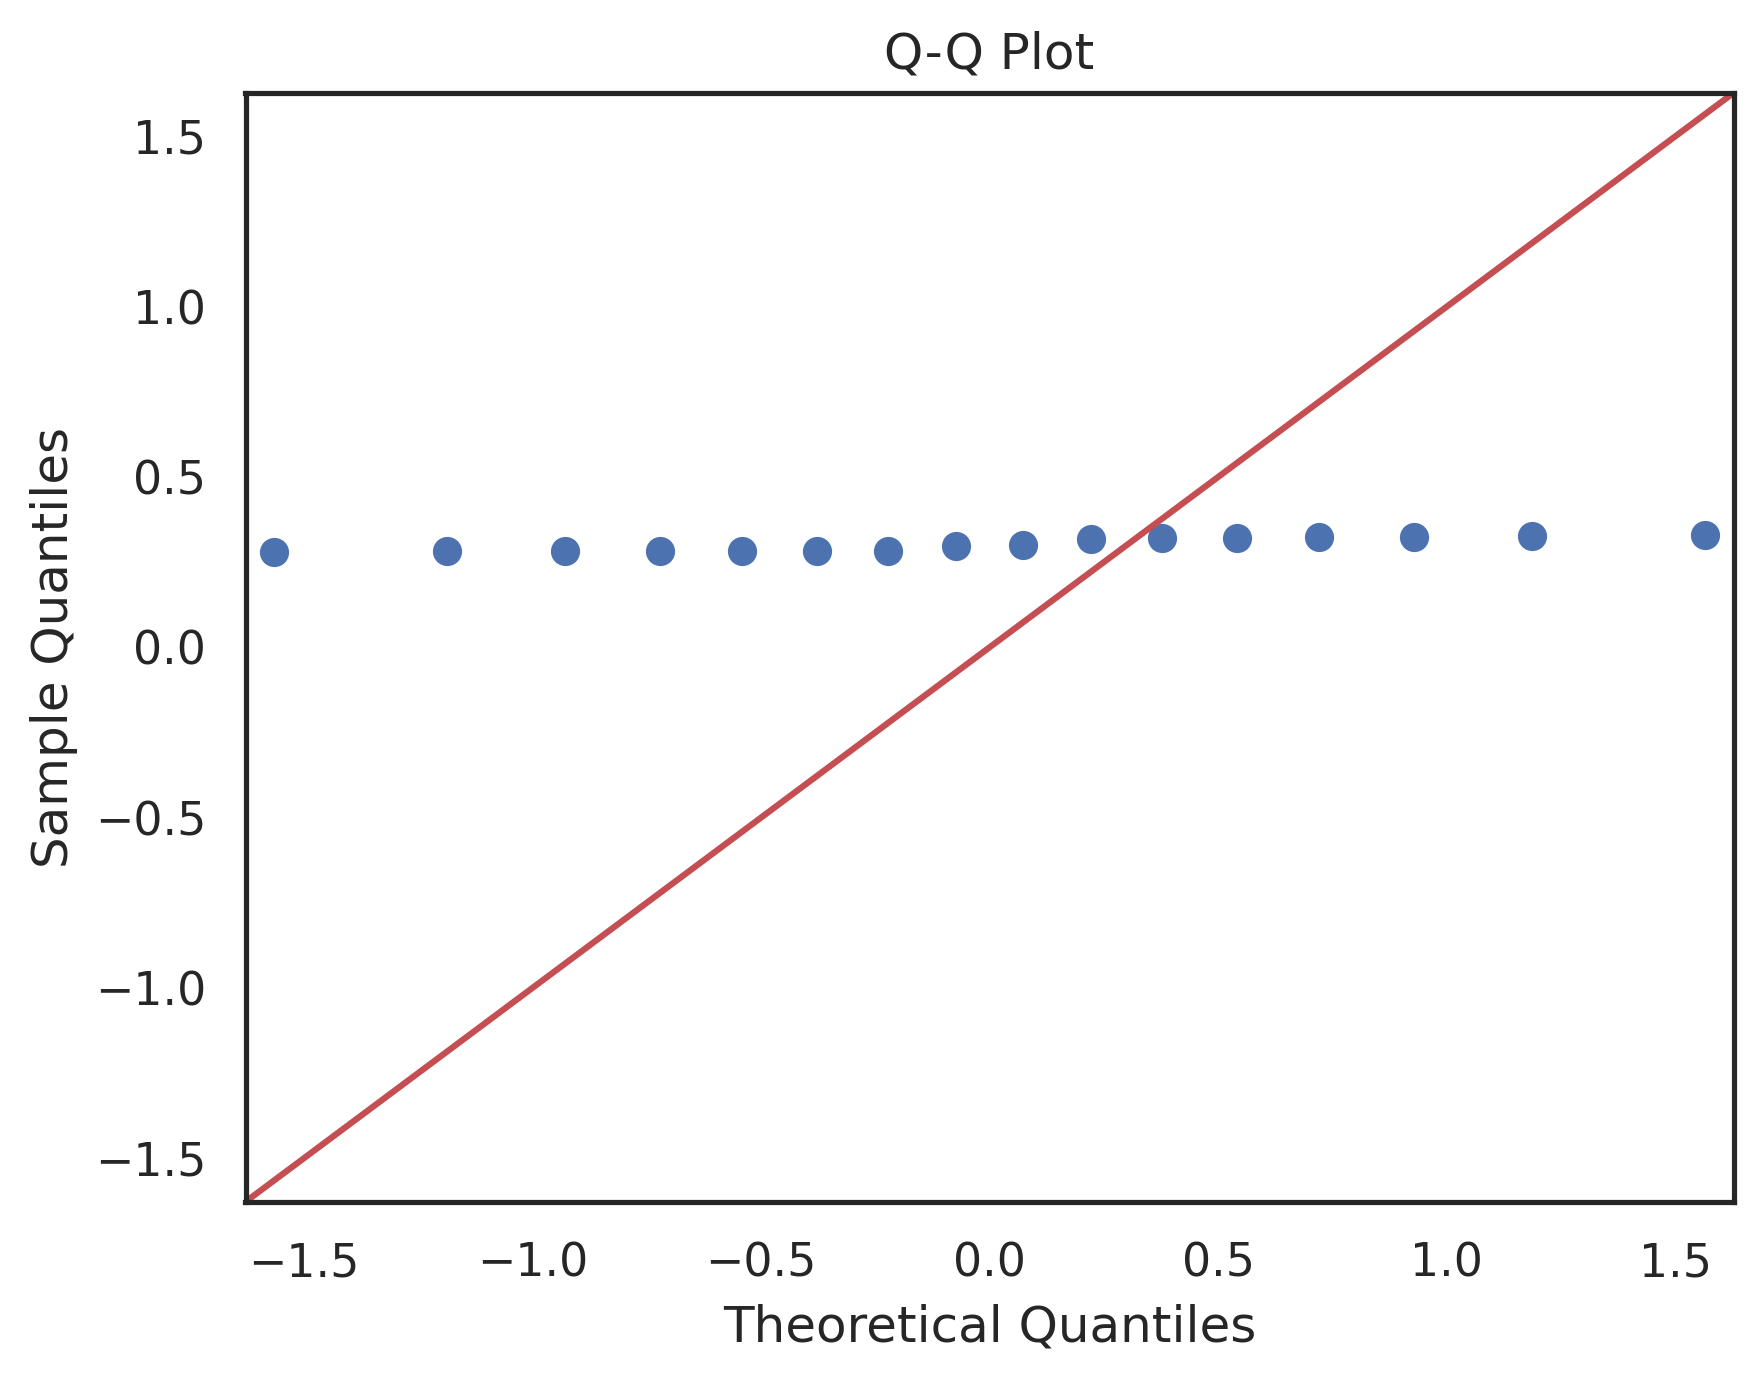

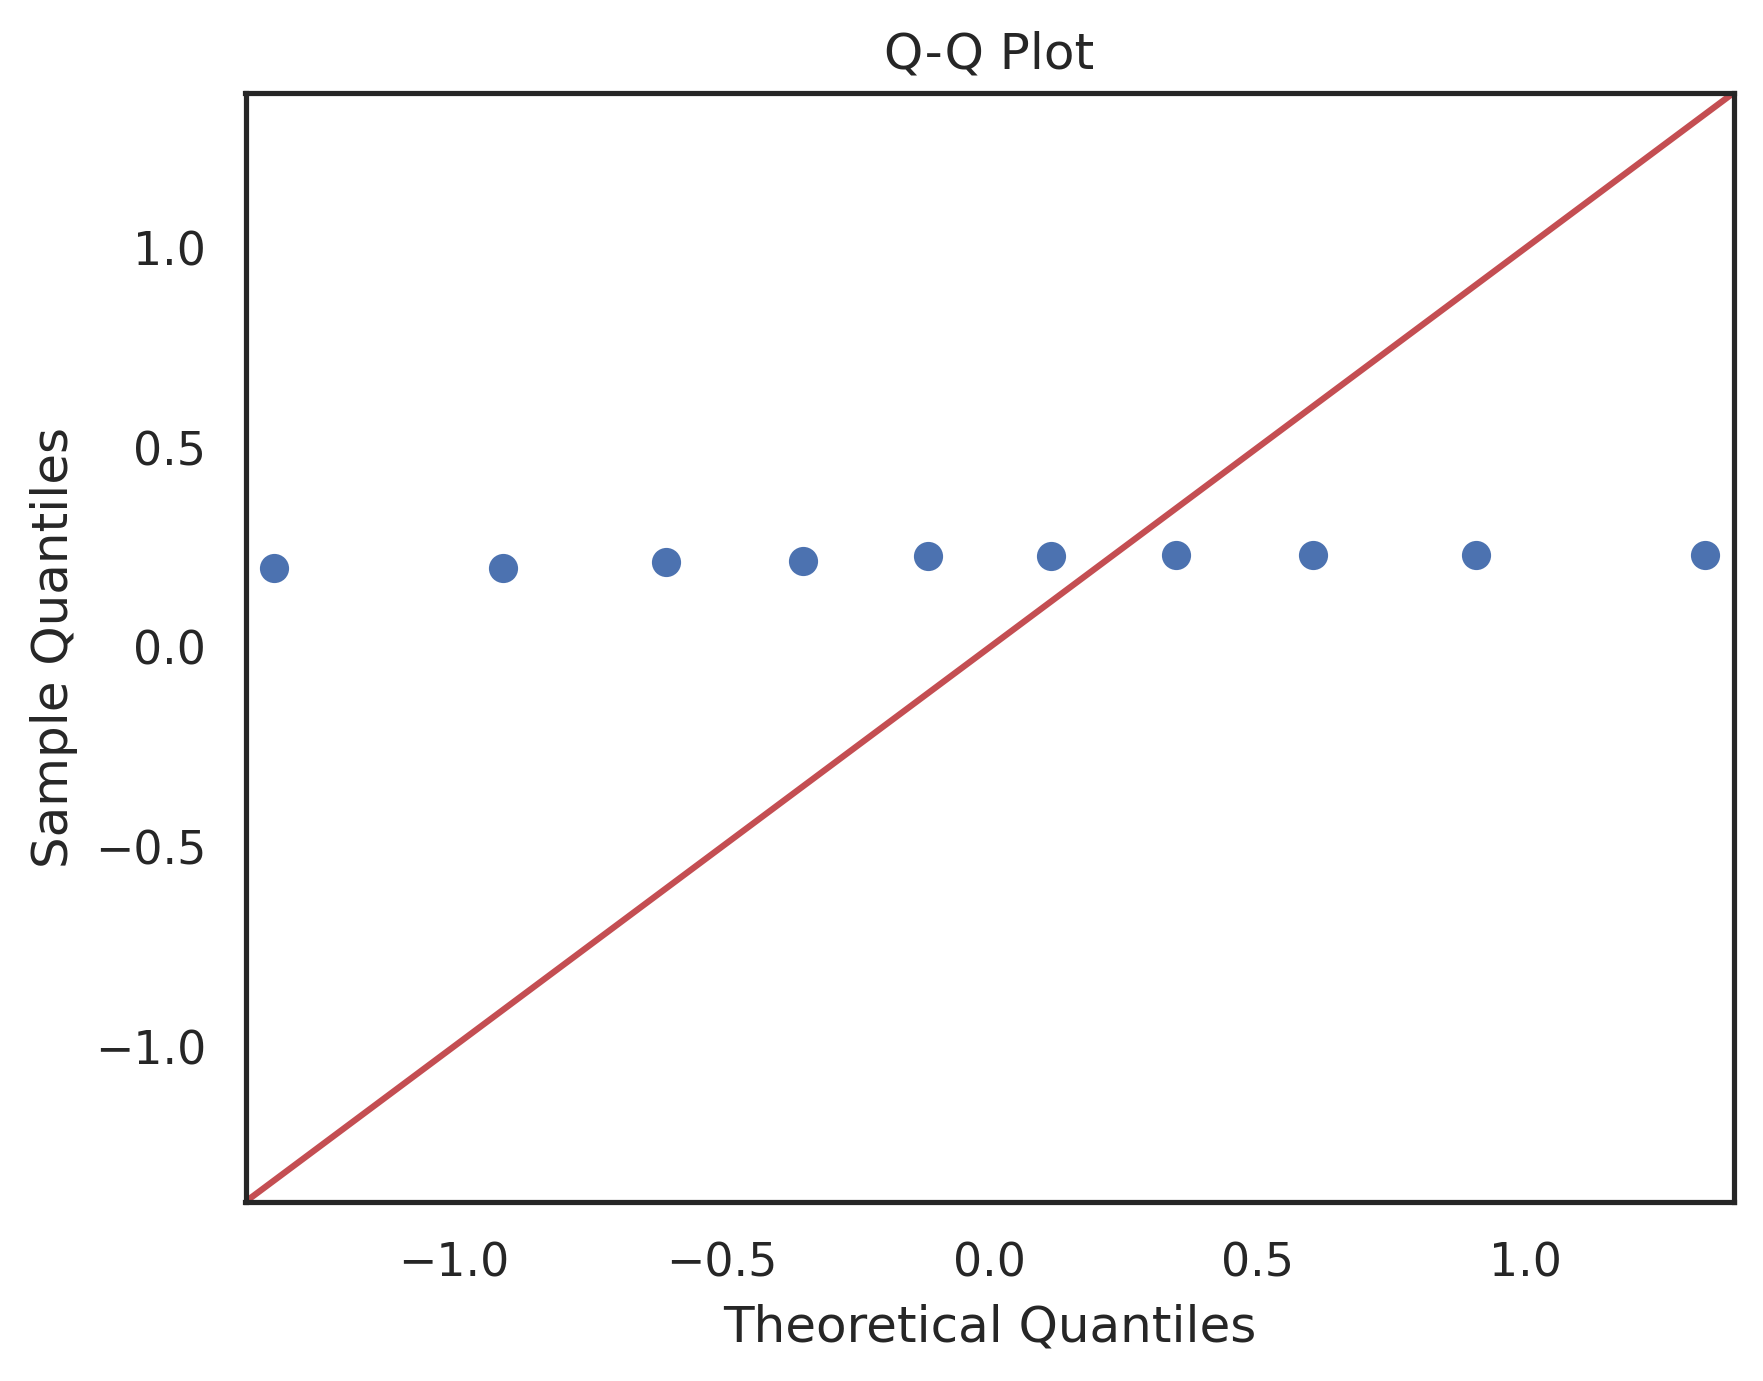

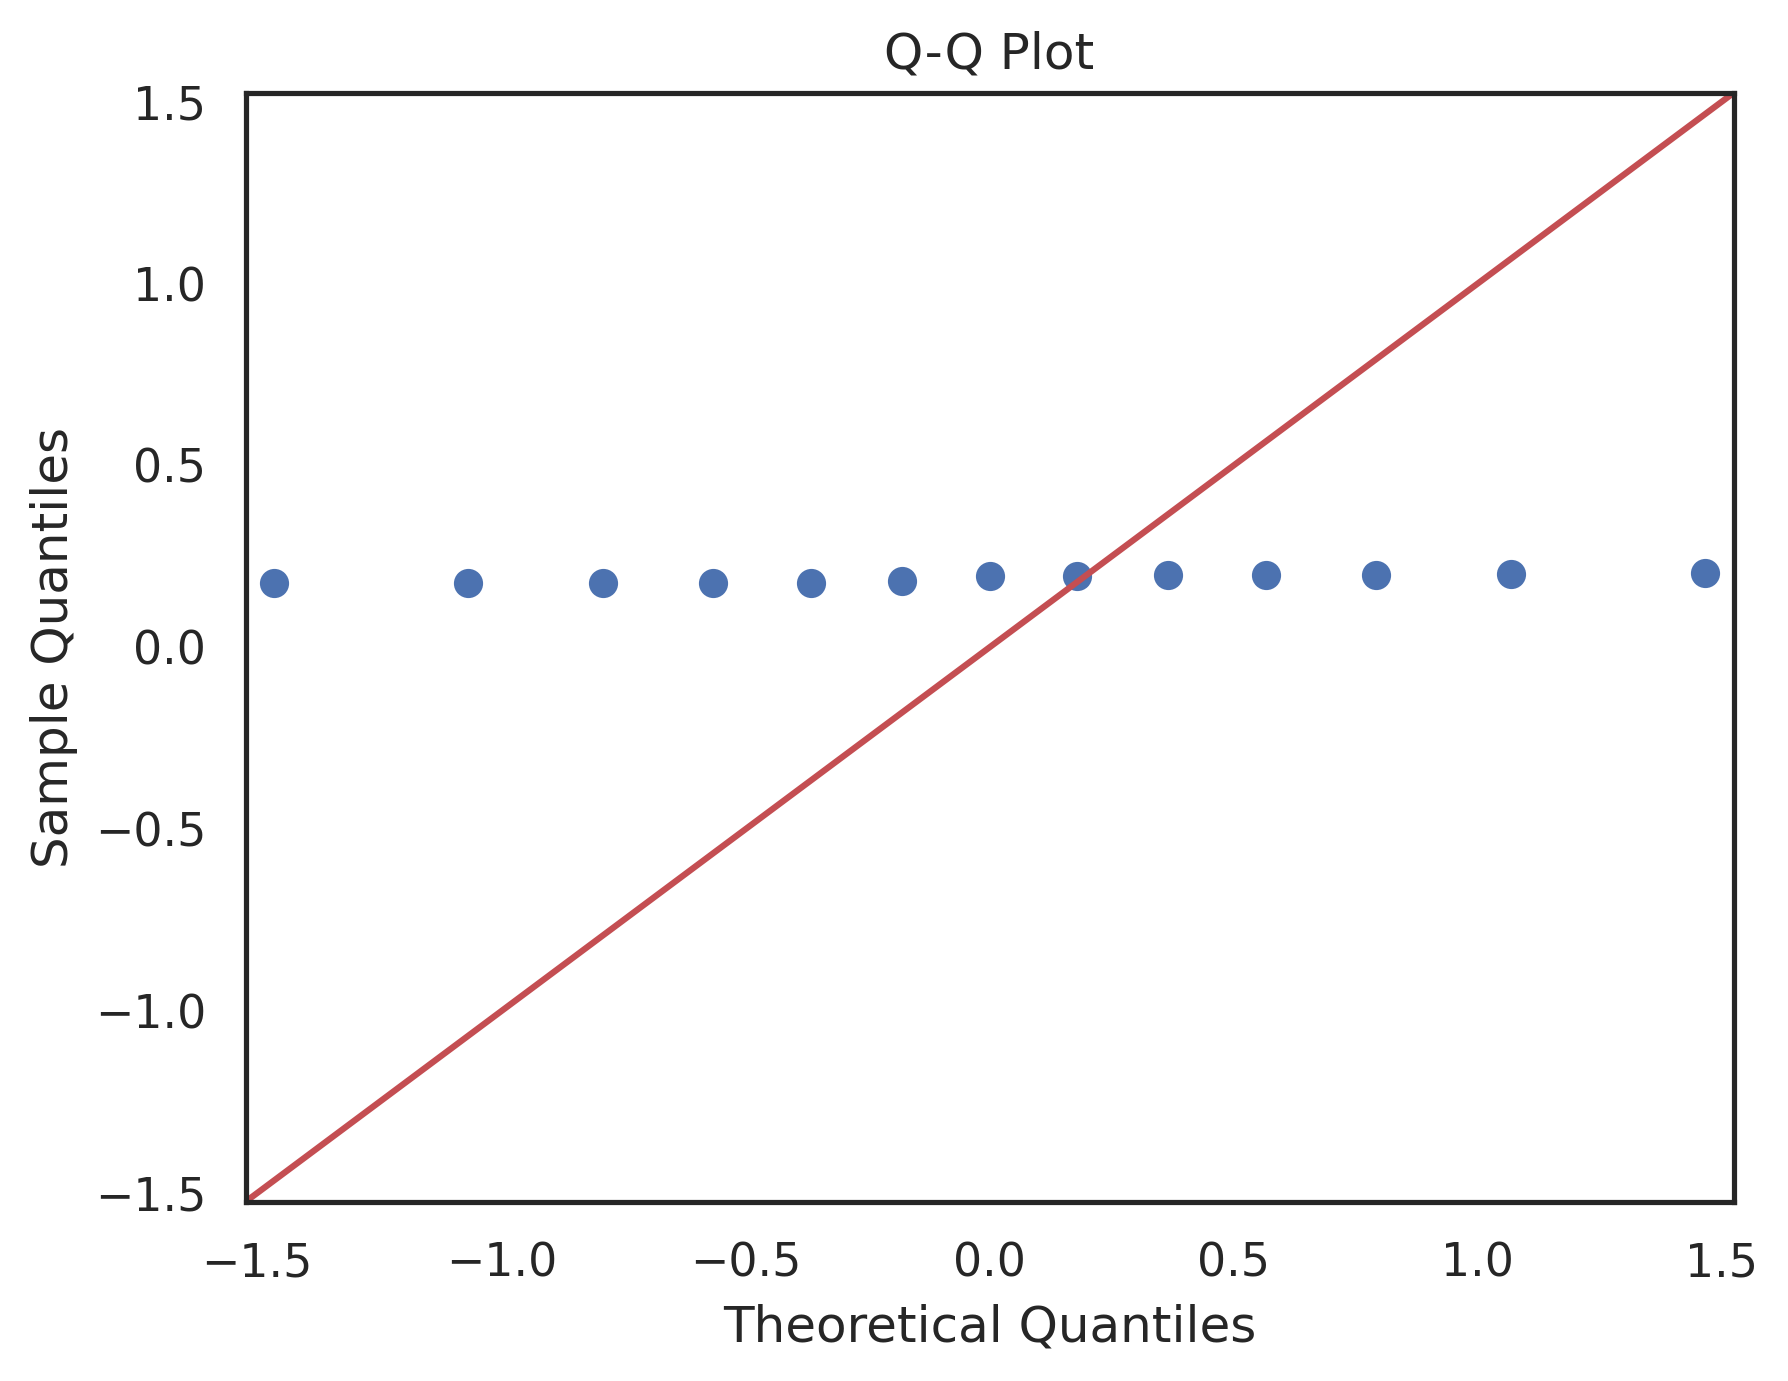

In [9]:
ps.generate_qq(dpp_energy, column=metric)

## Hypothesis Testing: Kruskal-Wallis

In [10]:
ps.test_hypothesis_kruskal(dpp_energy, column=metric)

(47.094004689070005, 3.3192067444783175e-10)

## Effect Size: Cliff's Delta

In [11]:
ps.calc_cliffs_delta(dpp_energy, column=metric)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",1.000000,large
1,"(8, 16)",1.000000,large
2,"(16, 32)",0.923077,large


## Effect Size: Percentage Improvement

In [12]:
ps.calc_groups_improvement(dpp_energy, column=metric)

,CPU-GROUPS,Mean Improvement,Median Improvement,Mean Delta,Median Delta
0,"(4, 8)",61.528709,60.131691,0.186228,0.179905
1,"(8, 16)",37.018665,30.514537,0.081773,0.069950
2,"(16, 32)",16.821512,17.327772,0.031808,0.033855
3,"(4, 32)",158.554604,145.209336,0.299808,0.283710


# Docking Antibody-Antigen Energy Analysis 

In [13]:
daa = pd.read_csv('./data/clean/data_daa.csv')
daa_energy = daa[['ConsumedEnergy', 'NCPUS']]

# Descriptive Analysis

In [14]:
for x in [4, 8, 16, 32]:
    group = ps.get_group(daa_energy, ncpus=x)
    print(group.describe())

       ConsumedEnergy  NCPUS
count       12.000000   12.0
mean         7.228333    4.0
std          0.400768    0.0
min          6.770000    4.0
25%          6.825000    4.0
50%          7.315000    4.0
75%          7.600000    4.0
max          7.650000    4.0
       ConsumedEnergy  NCPUS
count       14.000000   14.0
mean         4.512857    8.0
std          0.263071    0.0
min          4.190000    8.0
25%          4.217500    8.0
50%          4.575000    8.0
75%          4.750000    8.0
max          4.800000    8.0
       ConsumedEnergy  NCPUS
count       10.000000   10.0
mean         3.134000   16.0
std          0.189807    0.0
min          2.850000   16.0
25%          2.952500   16.0
50%          3.215000   16.0
75%          3.267500   16.0
max          3.310000   16.0
       ConsumedEnergy  NCPUS
count       11.000000   11.0
mean         2.668182   32.0
std          0.124645    0.0
min          2.460000   32.0
25%          2.595000   32.0
50%          2.700000   32.0
75%          2

## Boxplots

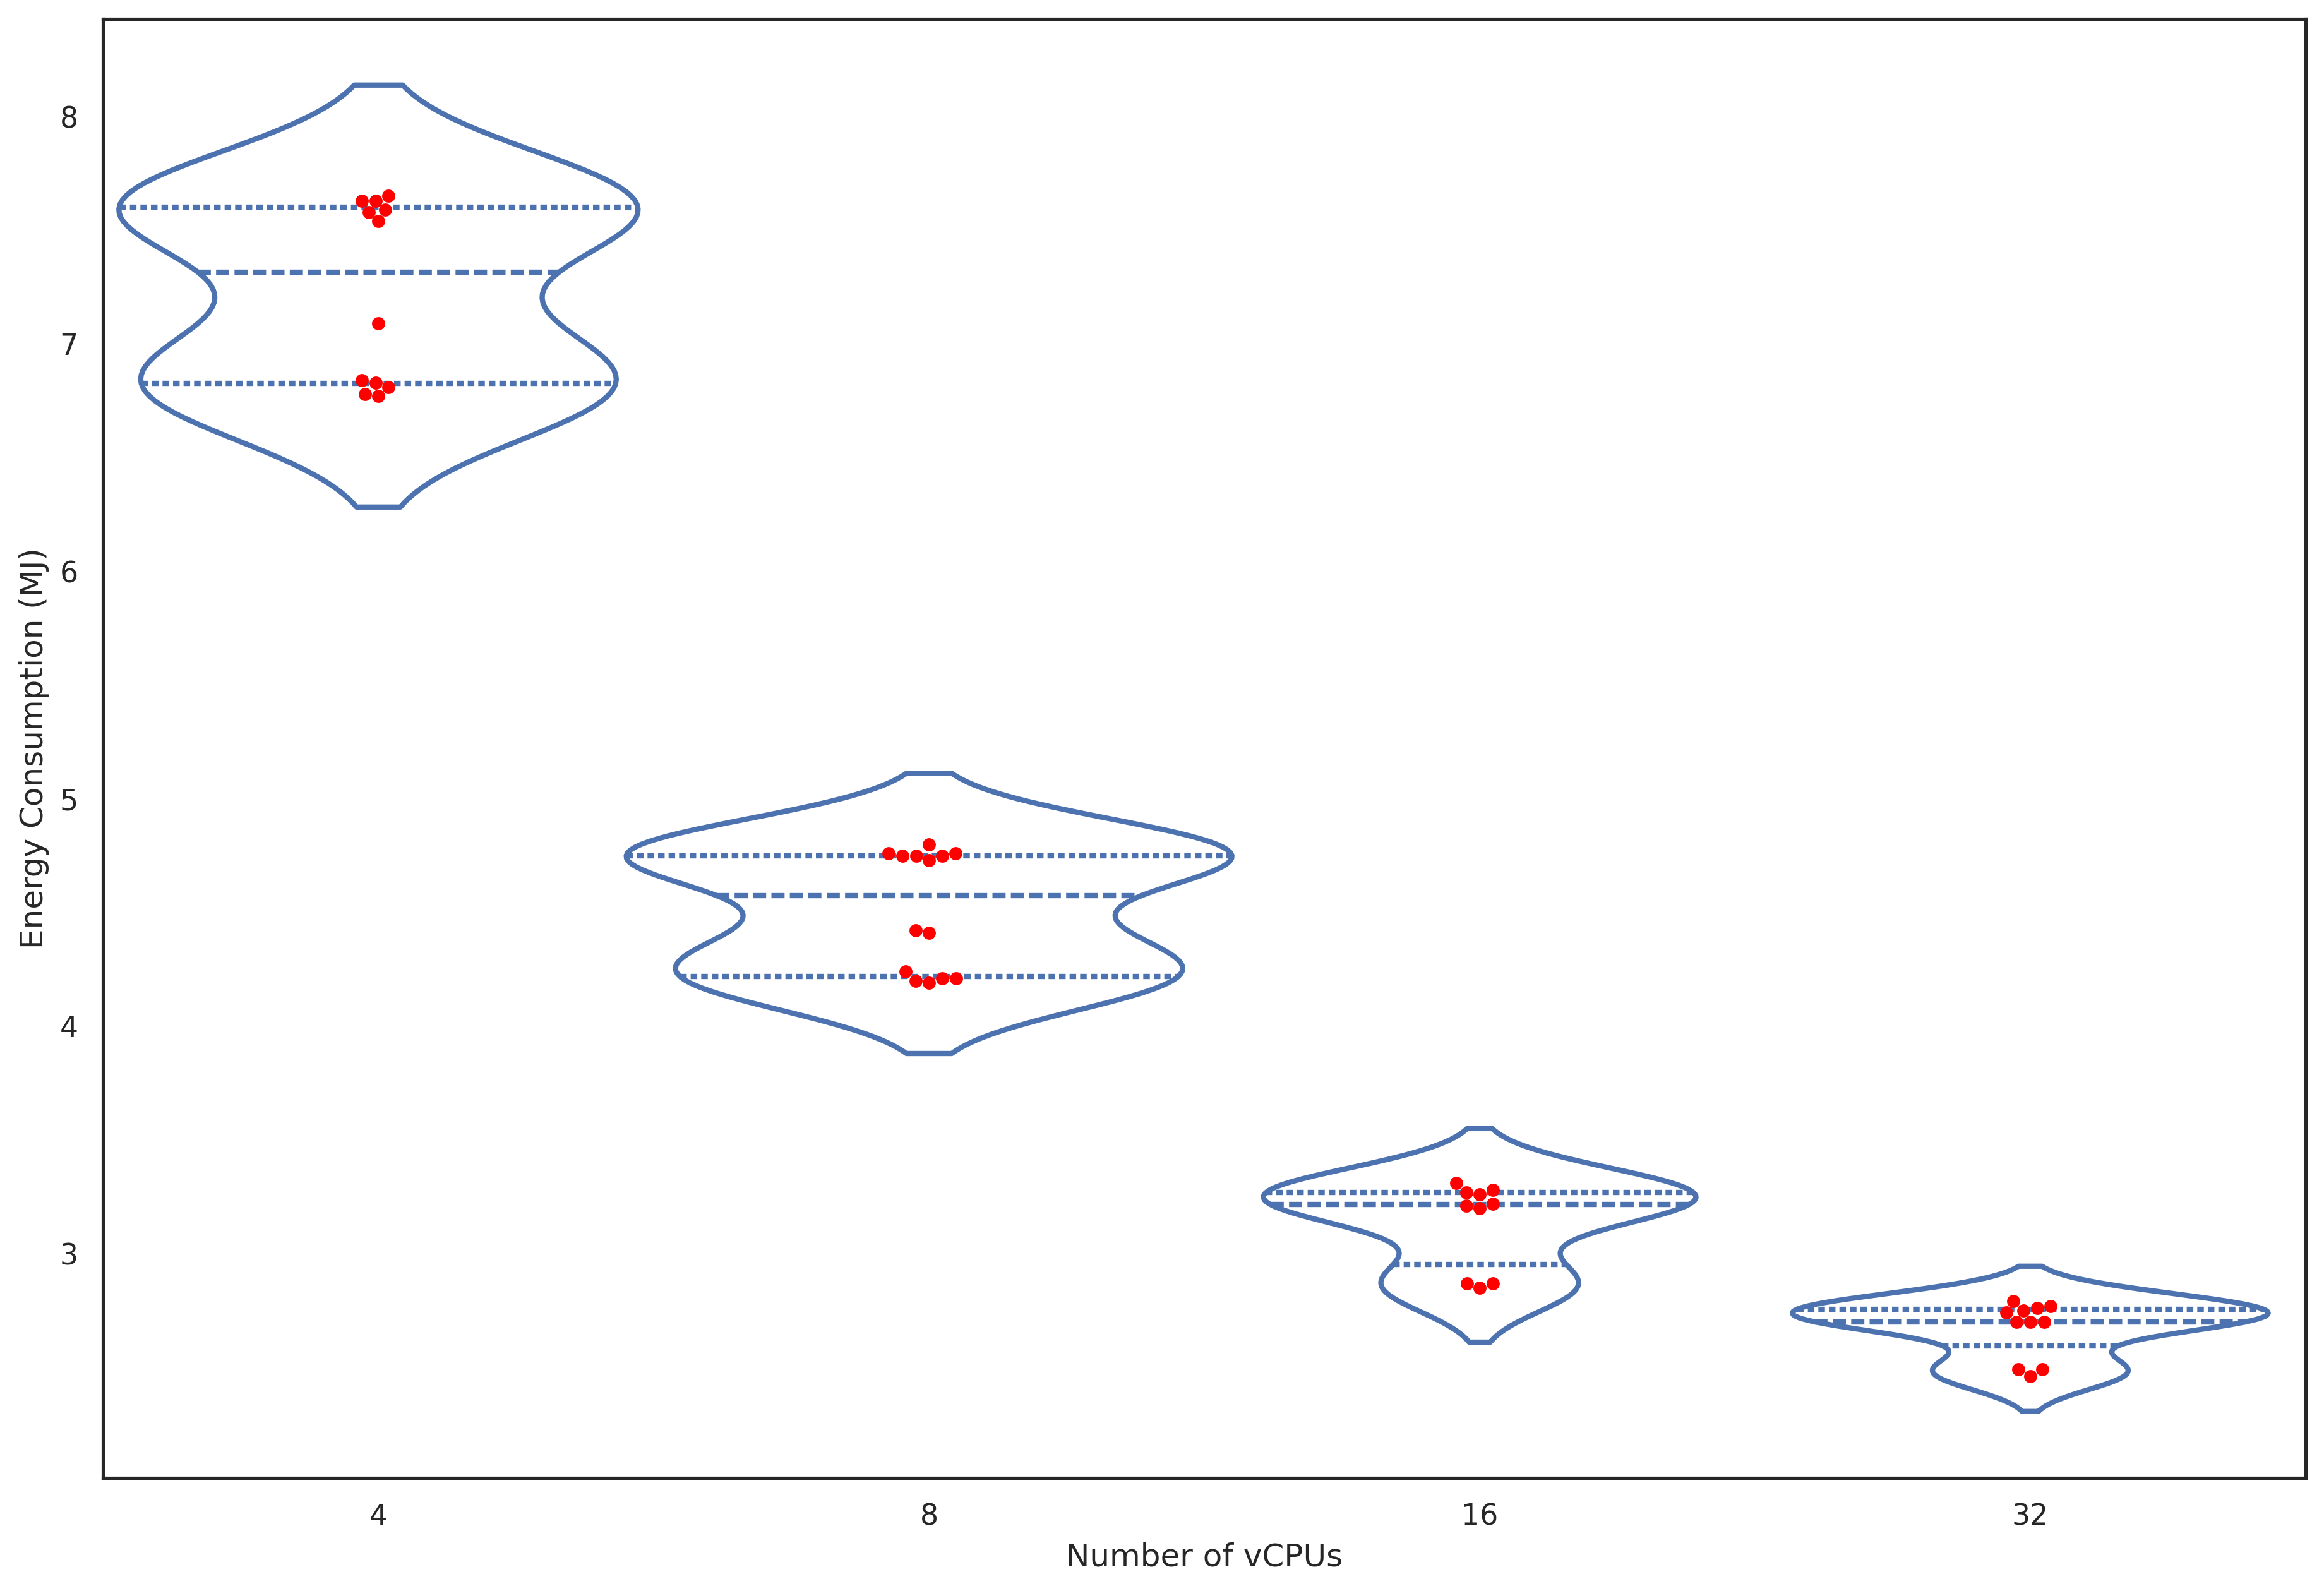

In [15]:
da.show_boxplot(
    daa_energy, "Energy Consumption of DAA Workflow at Varying Parallelism Degrees", metric='ConsumedEnergy',
    x_label="Number of vCPUs", y_label="Energy Consumption (MJ)", store=True
)

## Normality Test: Shapiro-Wilk and QQ-Plots

In [16]:
normality = ps.test_normality(daa_energy, column=metric)
print(normality)

   NCPUS      STAT    PVALUE
0      4  0.761013  0.003491
1      8  0.773452  0.002387
2     16  0.747452  0.003323
3     32  0.782205  0.005489


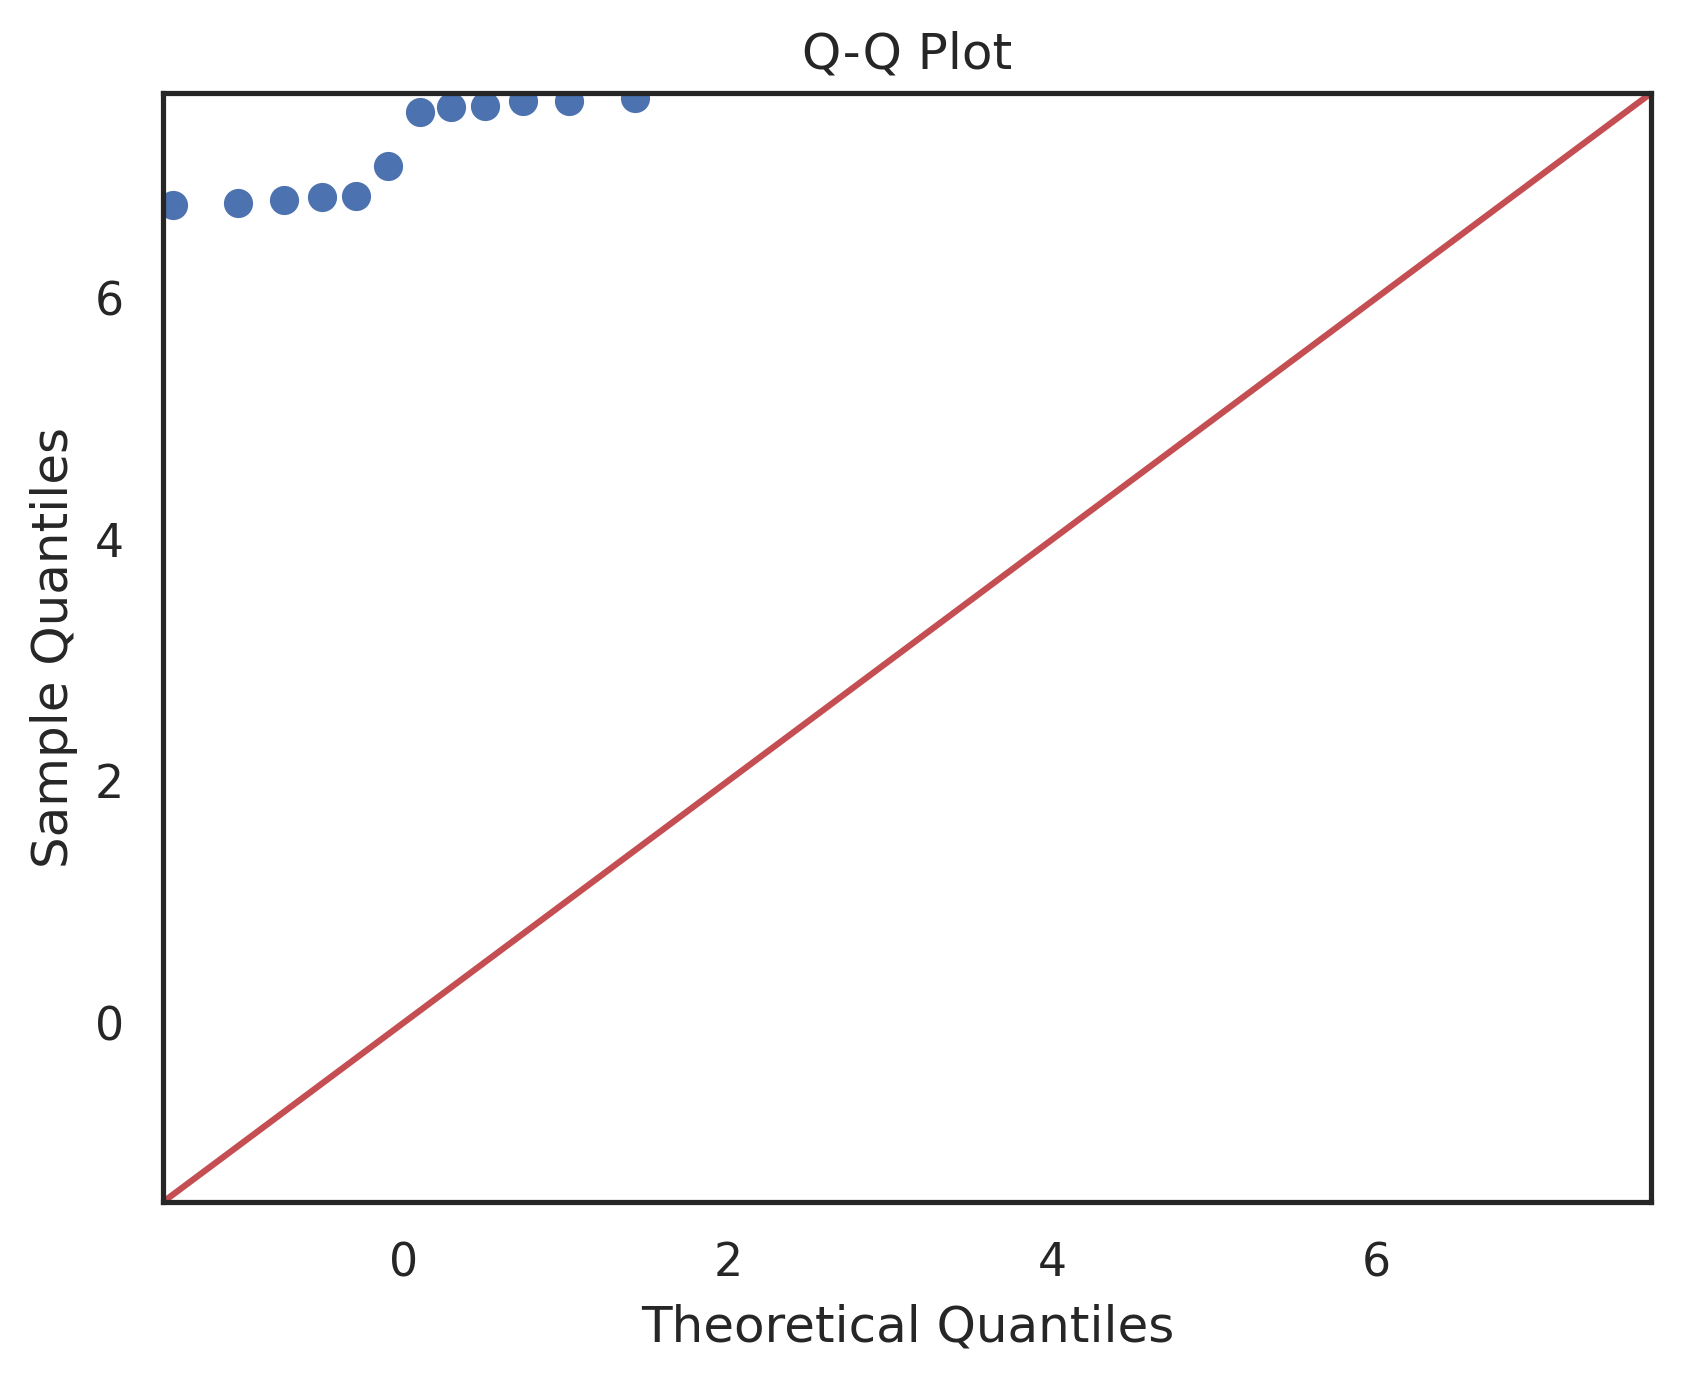

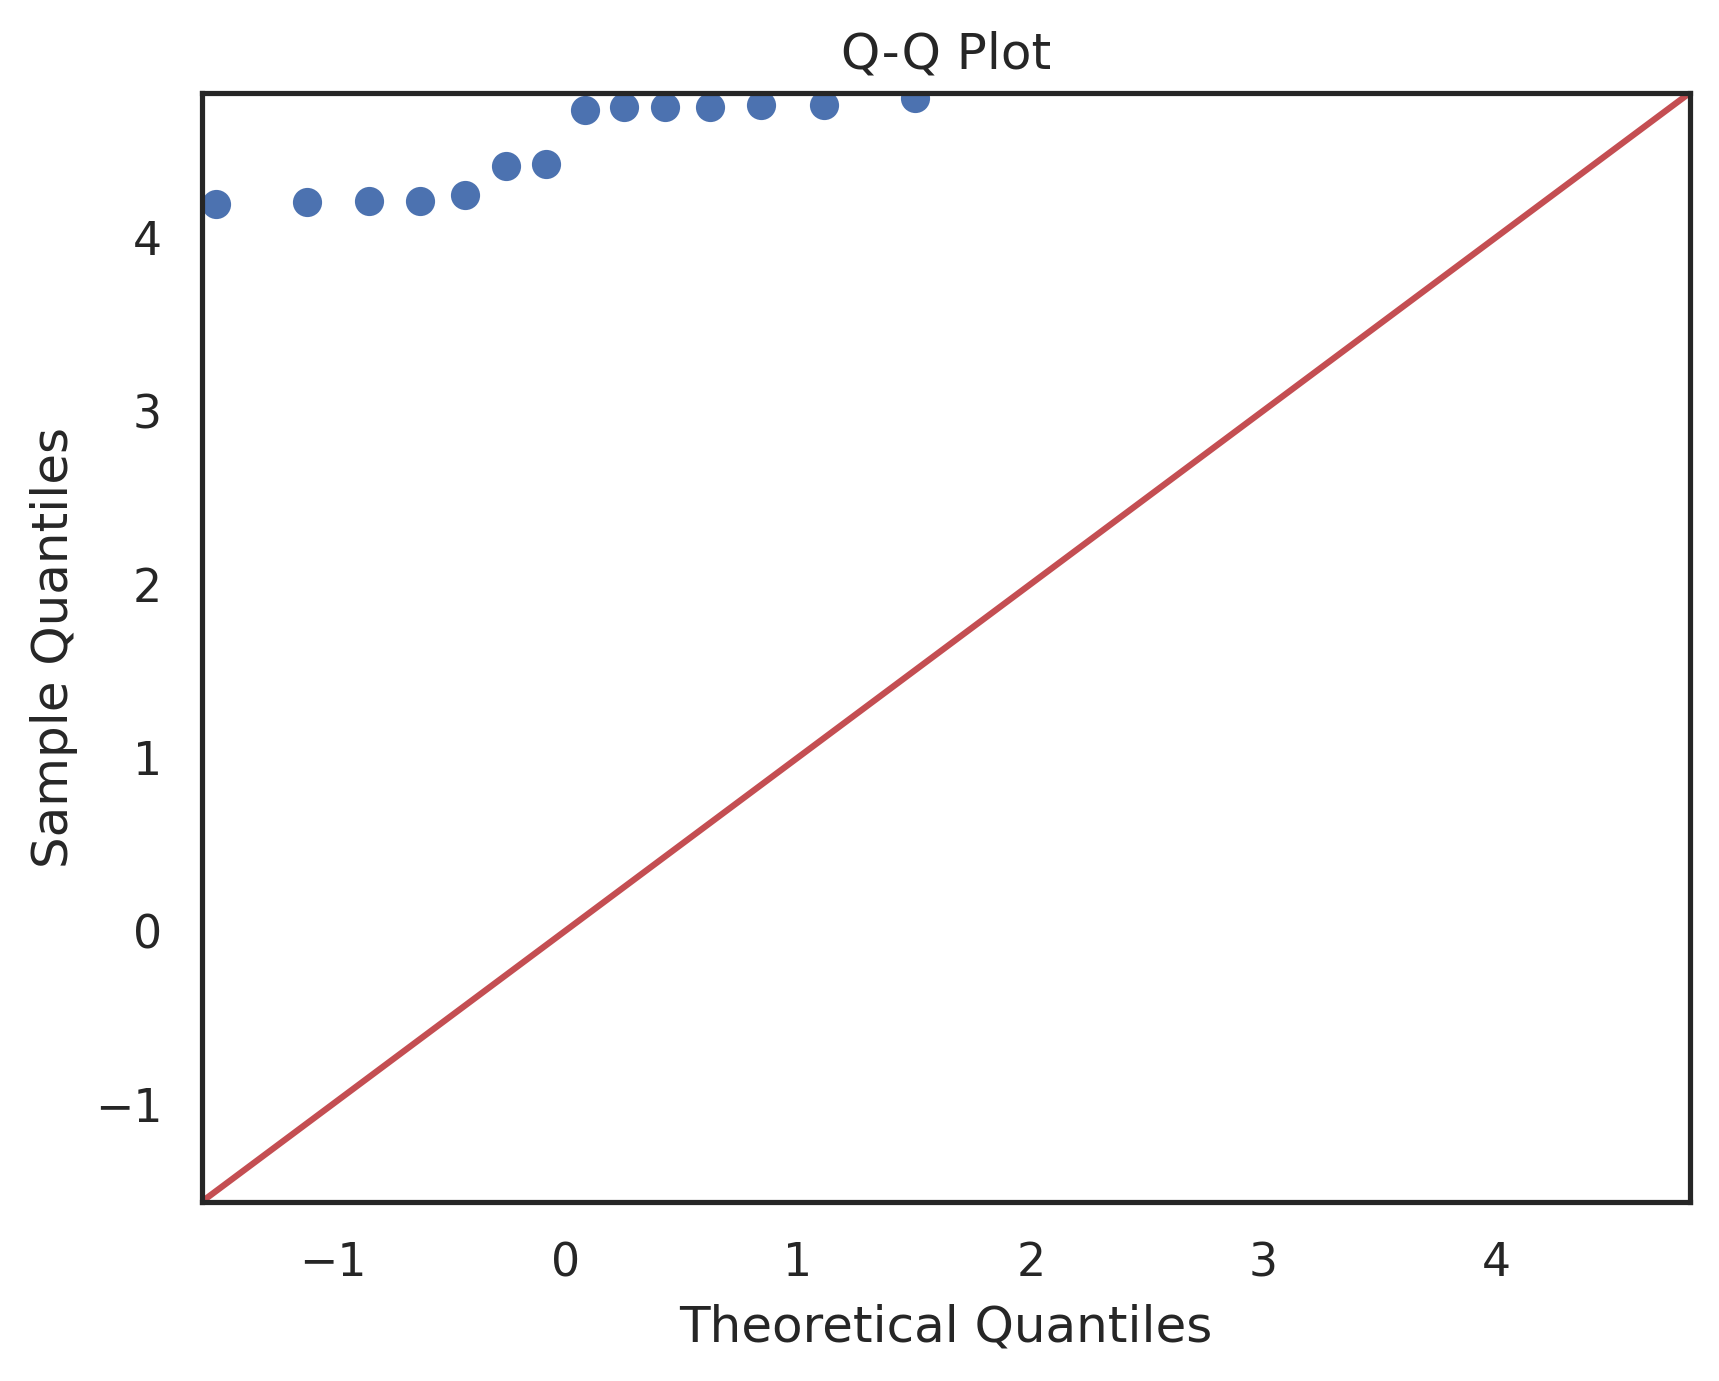

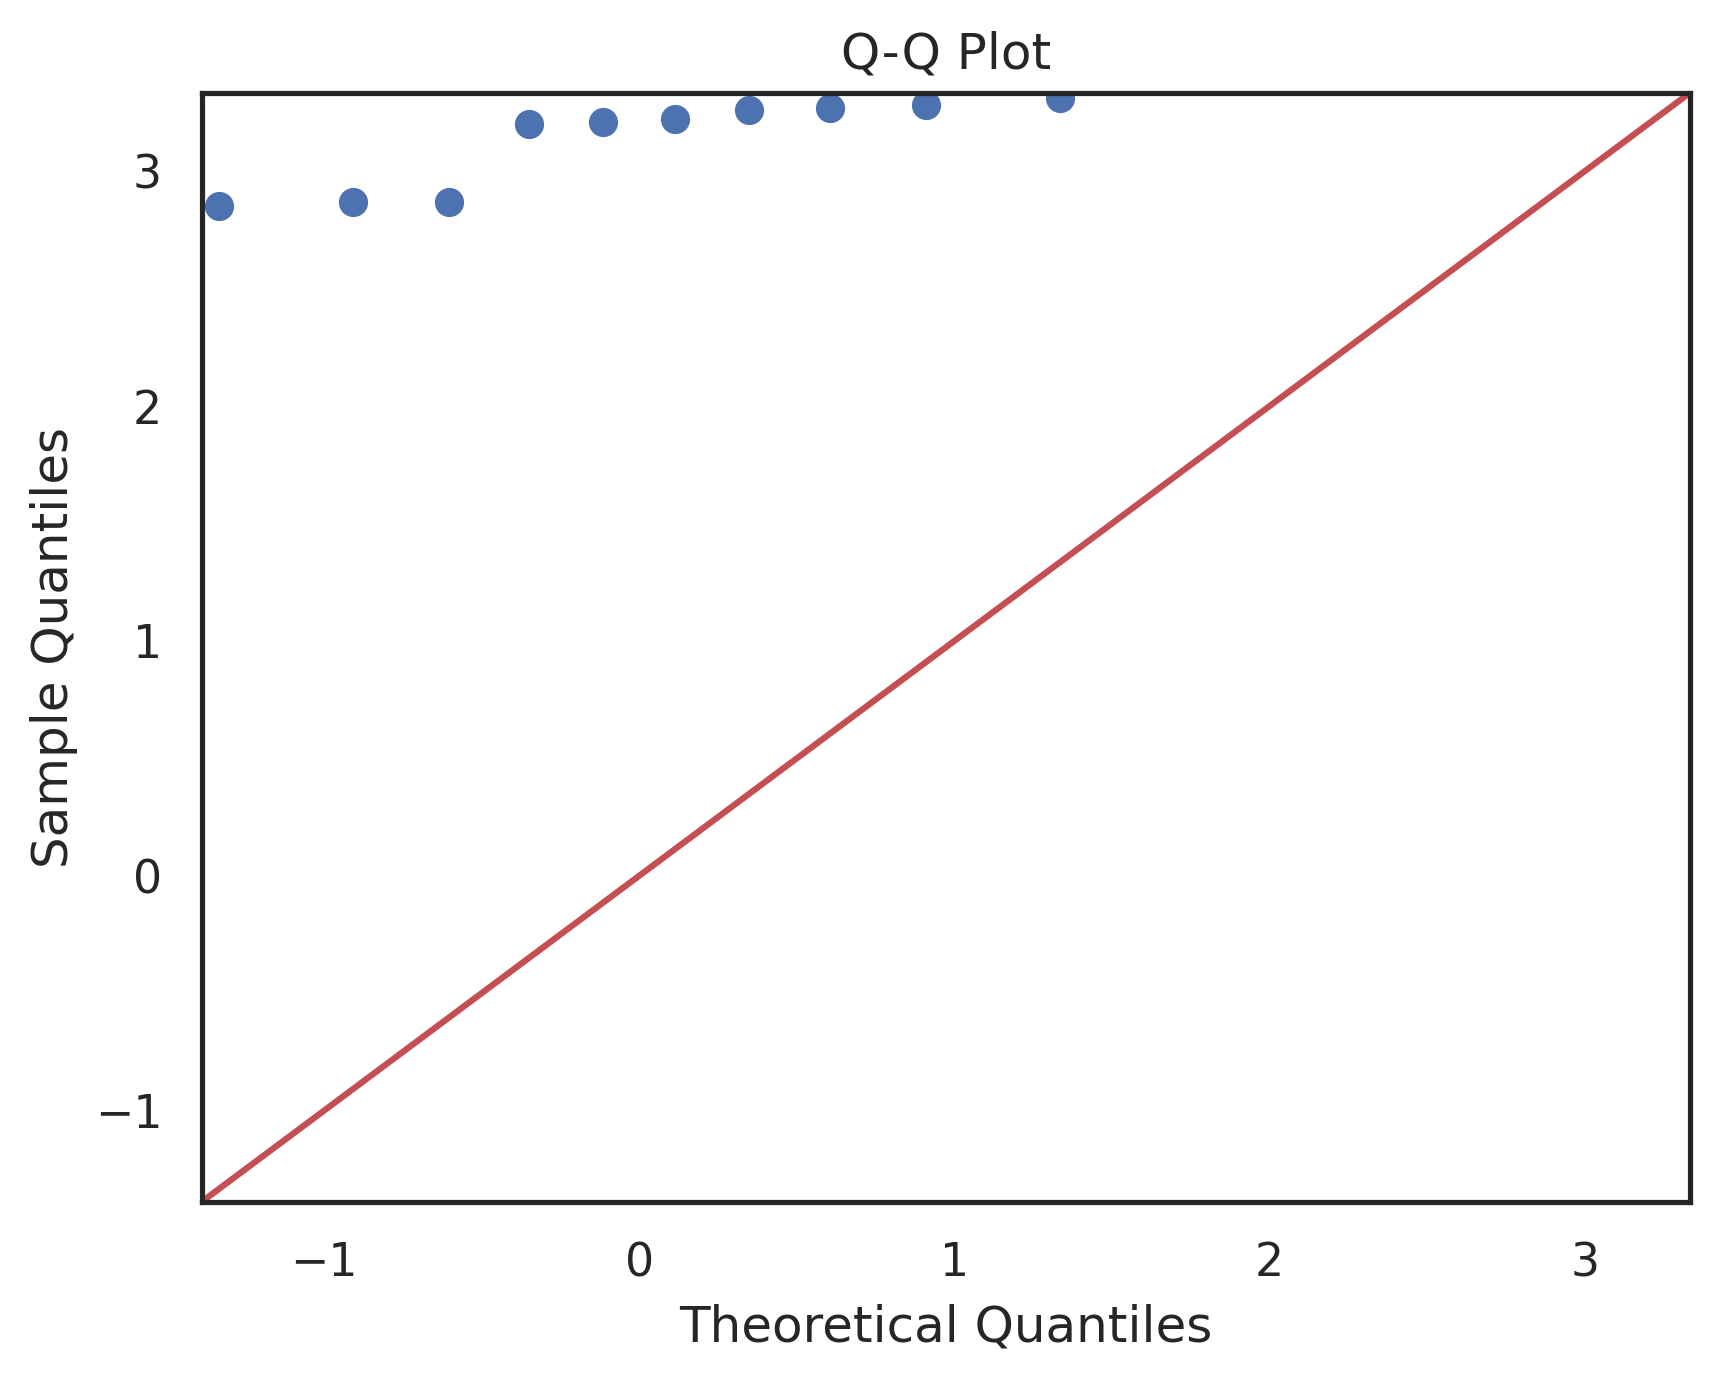

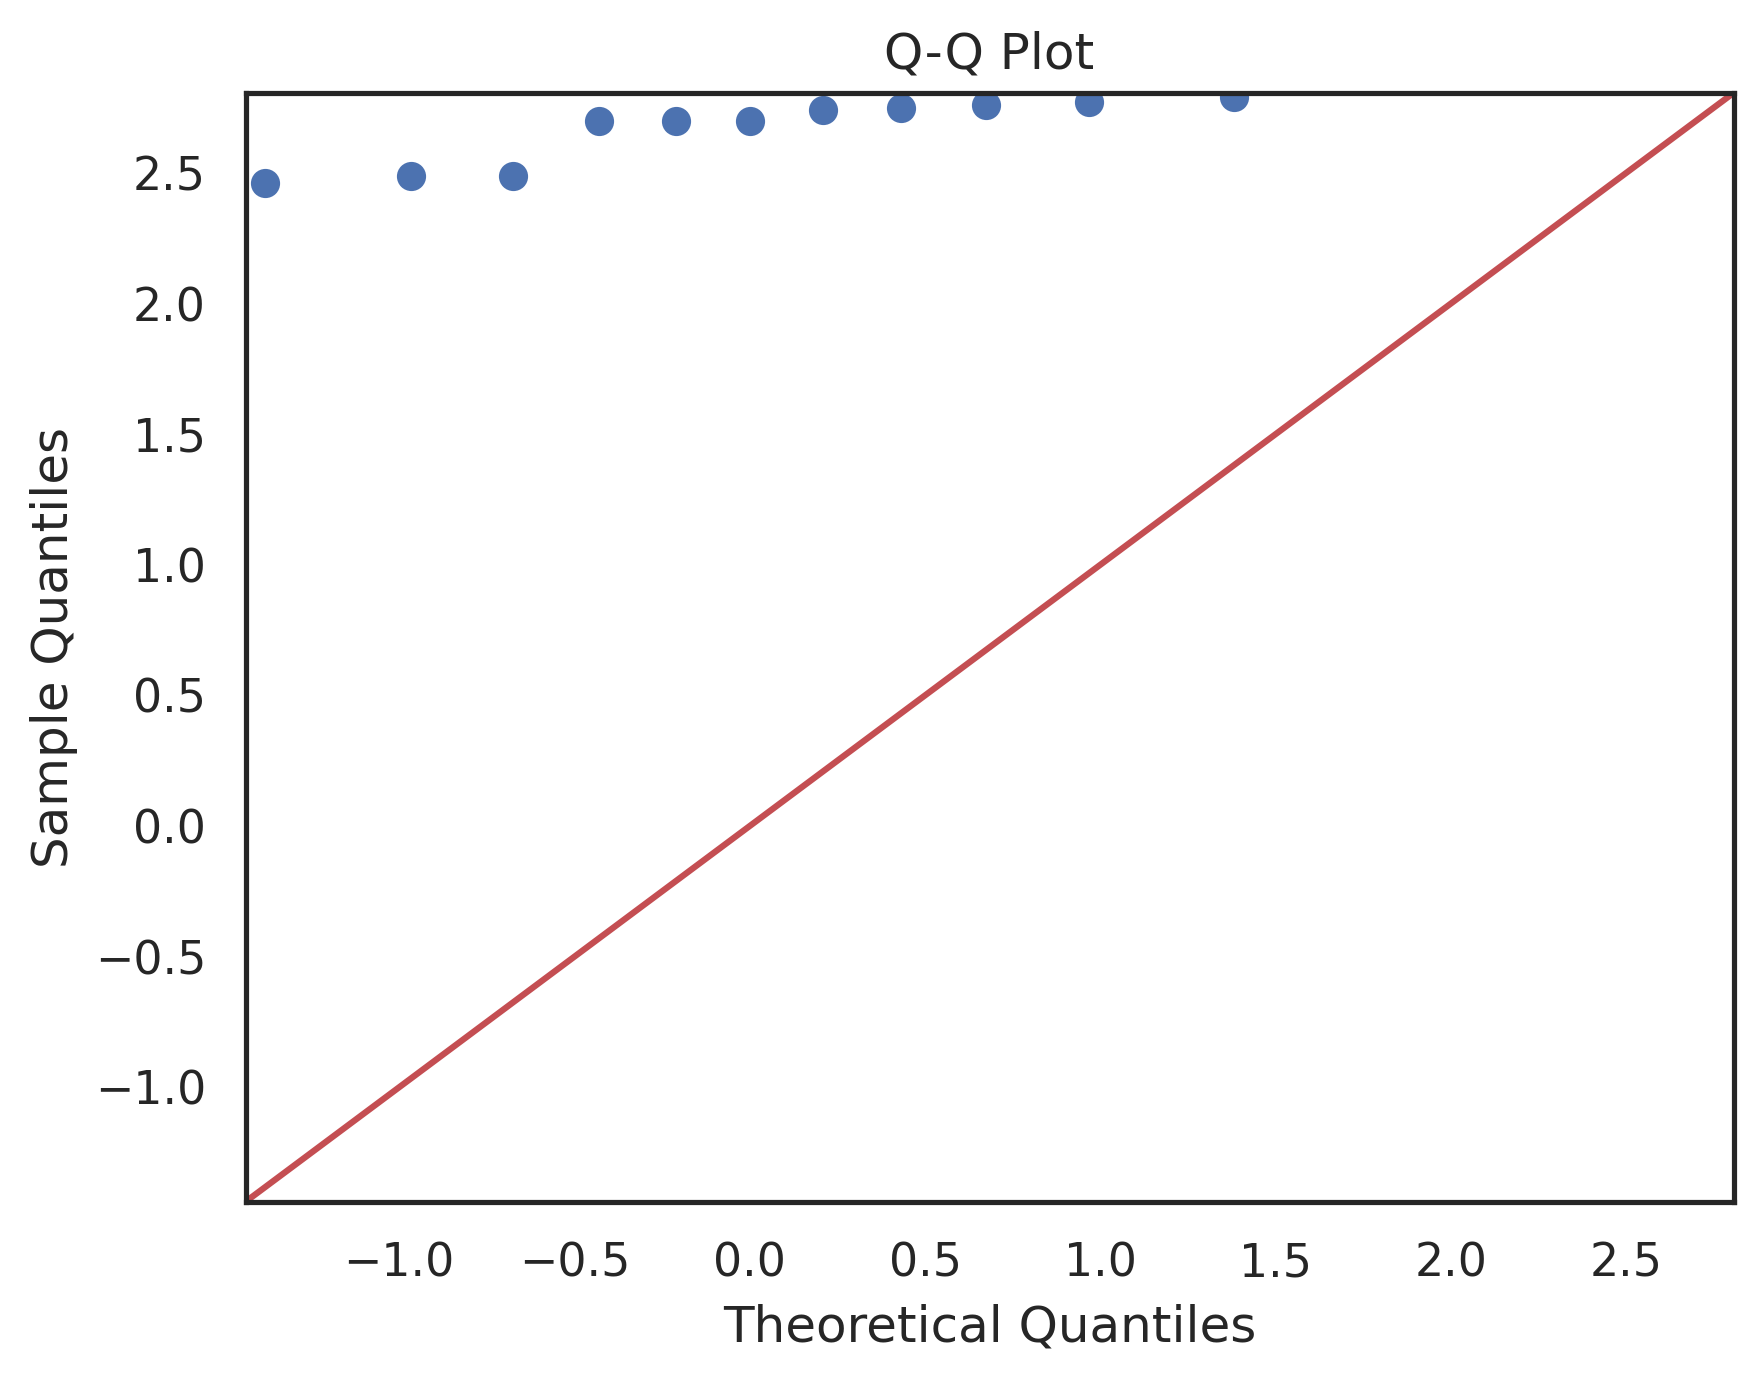

In [17]:
ps.generate_qq(daa_energy, column=metric)

## Hypothesis Testing: Kruskal-Wallis

In [18]:
ps.test_hypothesis_kruskal(daa_energy, column=metric)

(43.037667071688944, 2.4160978155904095e-09)

## Effect Size: Cliff's Delta

In [19]:
ps.calc_cliffs_delta(daa_energy)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",1.0,large
1,"(8, 16)",1.0,large
2,"(16, 32)",1.0,large


## Effect Size: Percentage Improvement

In [20]:
ps.calc_groups_improvement(daa_energy)

,CPU-GROUPS,Mean Improvement,Median Improvement,Mean Delta,Median Delta
0,"(4, 8)",60.171995,59.890710,2.715476,2.740
1,"(8, 16)",43.996718,42.301711,1.378857,1.360
2,"(16, 32)",17.458262,19.074074,0.465818,0.515
3,"(4, 32)",170.908575,170.925926,4.560152,4.615
